# 噪声与平滑

使用OpenCV给图像添加噪声，并使用不同的滤波方法对图像进行平滑处理。

## 噪声的分类

噪声是图像处理中常见的问题，根据其统计特性可以分为以下几类：

1. **高斯噪声**：服从高斯分布的噪声，常见于传感器噪声和电子噪声。

2. **椒盐噪声**：图像中随机出现的黑白点，通常由传输错误或传感器故障引起。

3. **斑点噪声**：一种乘性噪声，常见于雷达、超声成像等相干成像系统，噪声与原始像素值成比例，表现为颗粒状斑点。

4. **泊松噪声**：由光子统计波动引起，常见于低光照摄影和医学图像采集，噪声强度与信号强度相关。

5. **随机噪声**：传感器热噪声、量化误差、电子电路干扰等因素引起的随机亮度波动。


## 噪声添加

使用OpenCV和NumPy可以方便地向图像中添加噪声。以下是添加高斯噪声和椒盐噪声的示例代码：

```python
import cv2
import numpy as np

# 添加高斯噪声
def add_gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

# 添加椒盐噪声
def add_salt_pepper_noise(image, salt_prob=0.01, pepper_prob=0.01):
    noisy_image = image.copy()
    rows, cols = image.shape[:2]
    
    # 添加椒盐噪声
    salt_mask = np.random.rand(rows, cols) < salt_prob
    pepper_mask = np.random.rand(rows, cols) < pepper_prob
    
    noisy_image[salt_mask] = 255
    noisy_image[pepper_mask] = 0
    
    return noisy_image
```

In [1]:
import cv2
import numpy as np

# 添加高斯噪声
def add_gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

# 添加椒盐噪声
def add_salt_pepper_noise(image, salt_prob=0.01, pepper_prob=0.01):
    noisy_image = image.copy()
    rows, cols = image.shape[:2]
    
    # 添加椒盐噪声
    salt_mask = np.random.rand(rows, cols) < salt_prob
    pepper_mask = np.random.rand(rows, cols) < pepper_prob
    
    noisy_image[salt_mask] = 255
    noisy_image[pepper_mask] = 0
    
    return noisy_image

Saved: ../data/struct_gaussian.jpg ../data/struct_salt_pepper.jpg


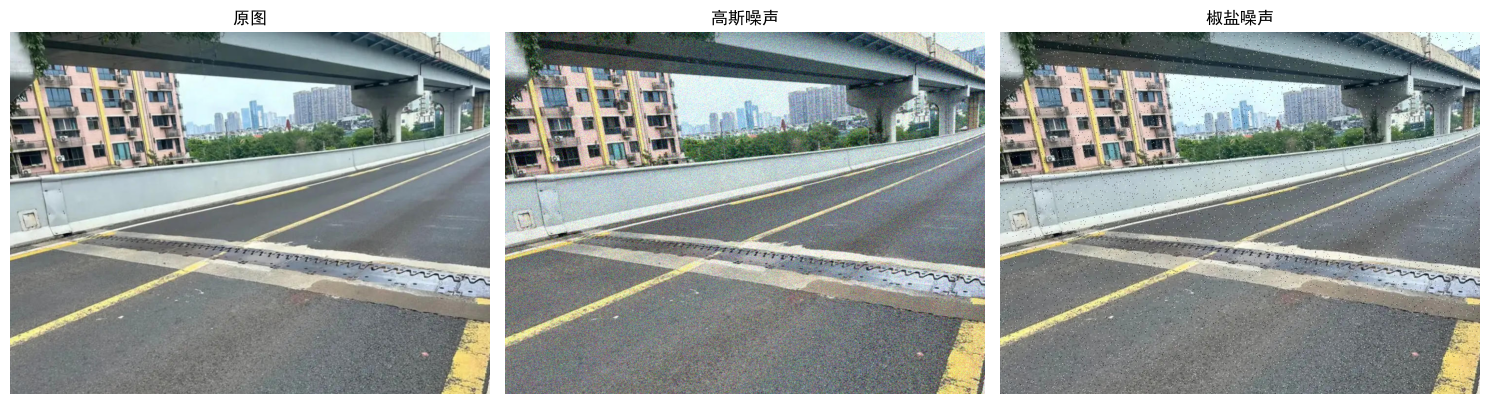

In [2]:
import platform

img_path = '../data/struct.jpg'
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {img_path}")

noisy_gaussian = add_gaussian_noise(img, mean=0, std=25)
noisy_salt_pepper = add_salt_pepper_noise(img, salt_prob=0.01, pepper_prob=0.01)

cv2.imwrite('../data/struct_gaussian.jpg', noisy_gaussian)
cv2.imwrite('../data/struct_salt_pepper.jpg', noisy_salt_pepper)

print('Saved:', '../data/struct_gaussian.jpg', '../data/struct_salt_pepper.jpg')

import matplotlib.pyplot as plt

if platform.system() == 'Windows':
    plt.rcParams['font.sans-serif'] = ['SimHei']
else:
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gauss_rgb = cv2.cvtColor(noisy_gaussian, cv2.COLOR_BGR2RGB)
sp_rgb = cv2.cvtColor(noisy_salt_pepper, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb); axes[0].set_title('原图'); axes[0].axis('off')
axes[1].imshow(gauss_rgb); axes[1].set_title('高斯噪声'); axes[1].axis('off')
axes[2].imshow(sp_rgb); axes[2].set_title('椒盐噪声'); axes[2].axis('off')
plt.tight_layout()
plt.show()

## 噪声过滤

接下来，我们使用`OpenCV`提供的几种滤波方法对添加噪声的图像进行平滑处理，包括均值滤波、高斯滤波、中值滤波和双边滤波。


### 高斯噪声处理

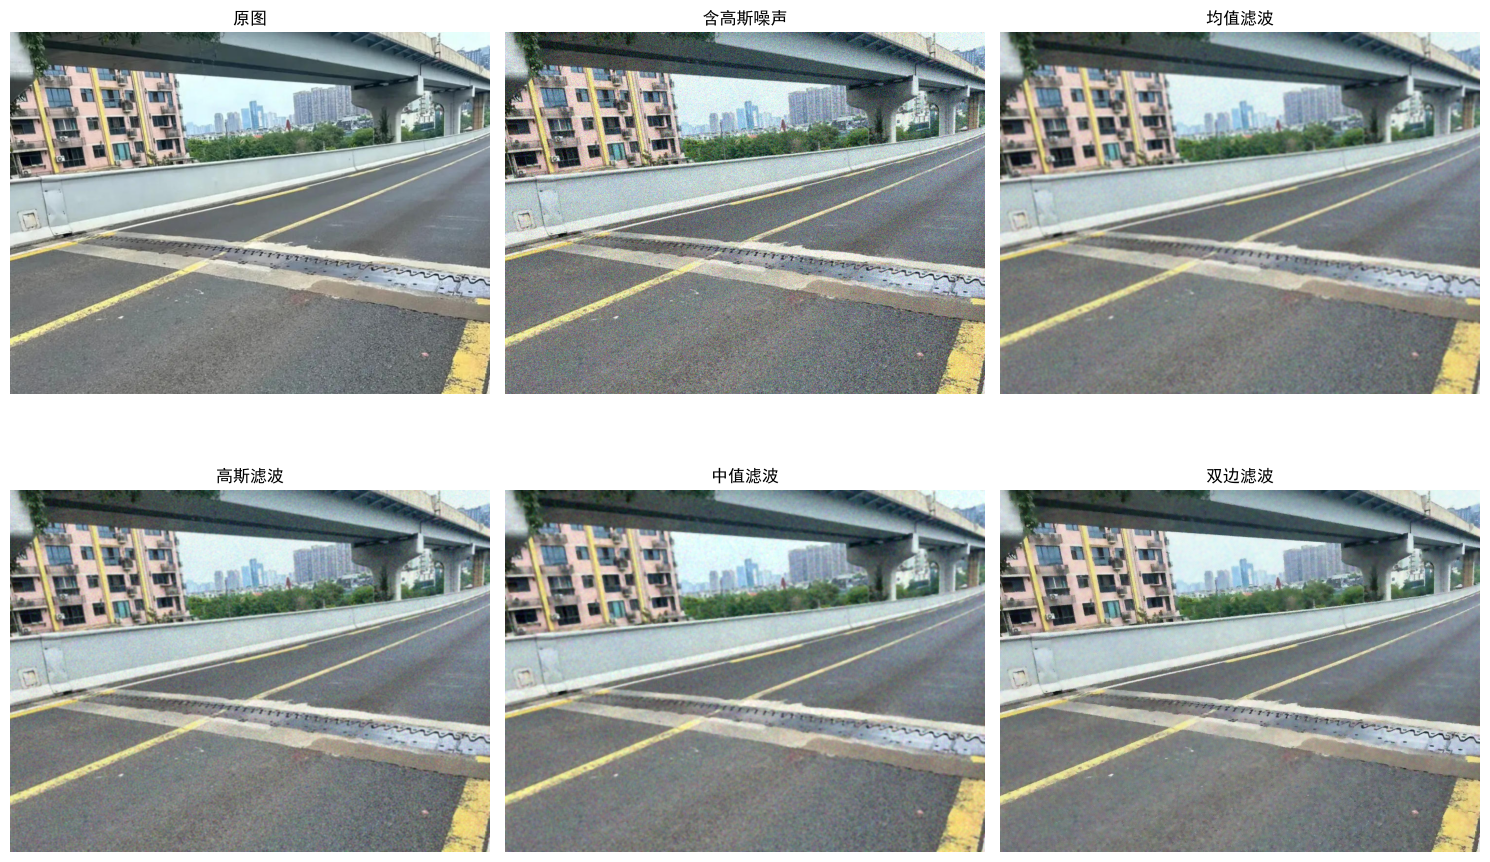

In [3]:
# 对 noisy_gaussian 分别应用均值、高斯、中值和双边滤波，并显示原图与结果
mean_filtered = cv2.blur(noisy_gaussian, (5, 5))
gaussian_filtered = cv2.GaussianBlur(noisy_gaussian, (5, 5), 0)
median_filtered = cv2.medianBlur(noisy_gaussian, 5)
bilateral_filtered = cv2.bilateralFilter(noisy_gaussian, 9, 75, 75)

# 转为 RGB 用于 matplotlib 显示
orig_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
noisy_rgb = cv2.cvtColor(noisy_gaussian, cv2.COLOR_BGR2RGB)
mean_rgb = cv2.cvtColor(mean_filtered, cv2.COLOR_BGR2RGB)
gauss_rgb = cv2.cvtColor(gaussian_filtered, cv2.COLOR_BGR2RGB)
median_rgb = cv2.cvtColor(median_filtered, cv2.COLOR_BGR2RGB)
bilat_rgb = cv2.cvtColor(bilateral_filtered, cv2.COLOR_BGR2RGB)

titles = ['原图', '含高斯噪声', '均值滤波', '高斯滤波', '中值滤波', '双边滤波']
images = [orig_rgb, noisy_rgb, mean_rgb, gauss_rgb, median_rgb, bilat_rgb]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, im, t in zip(axes.ravel(), images, titles):
    ax.imshow(im)
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()

### 椒盐噪声处理

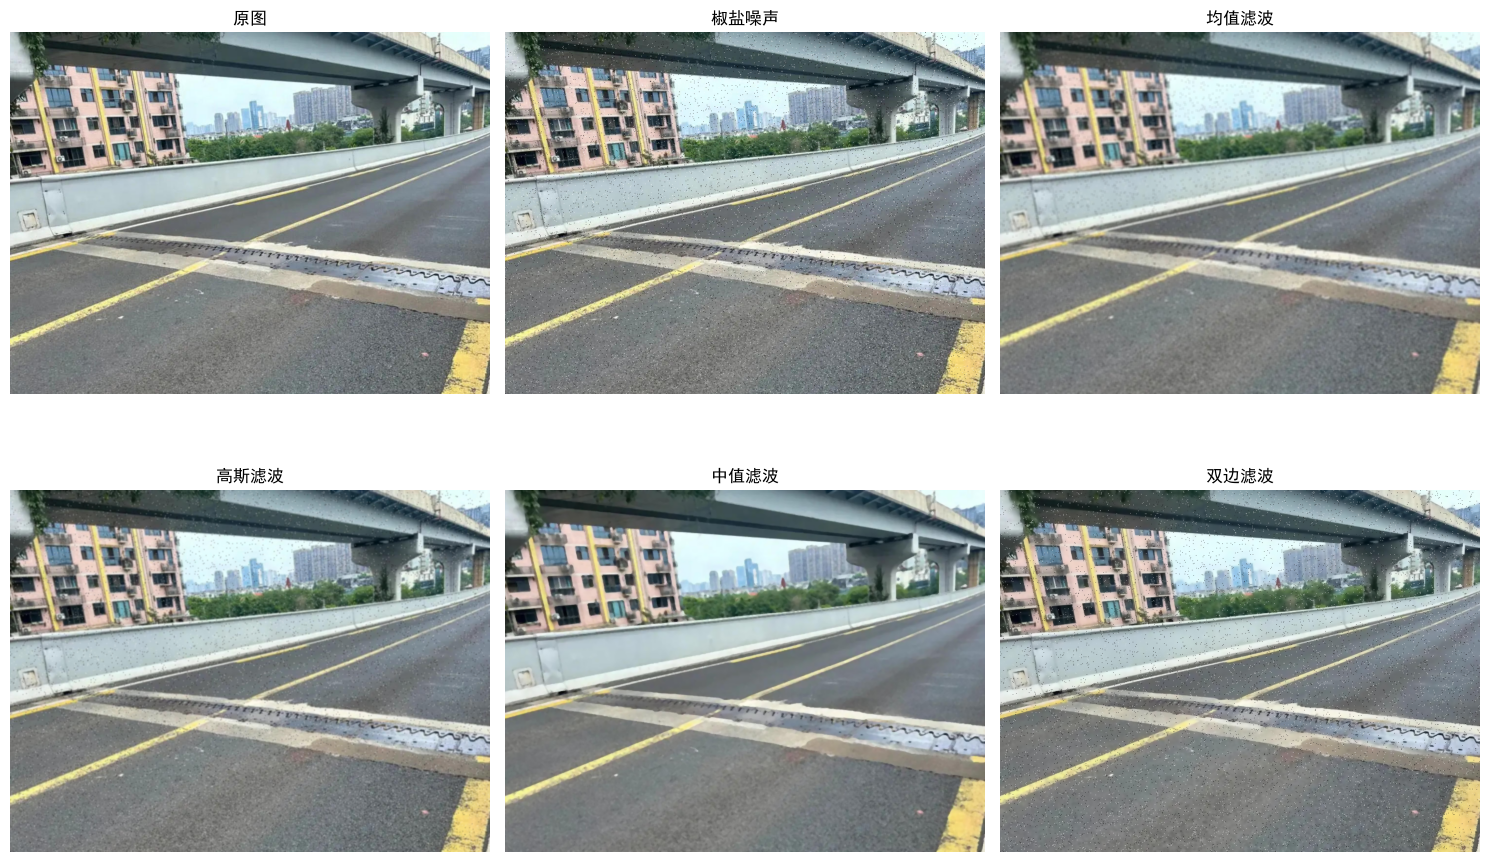

In [4]:
# 对 noisy_salt_pepper 分别应用均值、高斯、中值和双边滤波，并显示原图与结果
mean_filtered_sp = cv2.blur(noisy_salt_pepper, (5, 5))
gaussian_filtered_sp = cv2.GaussianBlur(noisy_salt_pepper, (5, 5), 0)
median_filtered_sp = cv2.medianBlur(noisy_salt_pepper, 5)
bilateral_filtered_sp = cv2.bilateralFilter(noisy_salt_pepper, 9, 75, 75)

orig_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
noisy_sp_rgb = cv2.cvtColor(noisy_salt_pepper, cv2.COLOR_BGR2RGB)
mean_sp_rgb = cv2.cvtColor(mean_filtered_sp, cv2.COLOR_BGR2RGB)
gauss_sp_rgb = cv2.cvtColor(gaussian_filtered_sp, cv2.COLOR_BGR2RGB)
median_sp_rgb = cv2.cvtColor(median_filtered_sp, cv2.COLOR_BGR2RGB)
bilat_sp_rgb = cv2.cvtColor(bilateral_filtered_sp, cv2.COLOR_BGR2RGB)

titles = ['原图', '椒盐噪声', '均值滤波', '高斯滤波', '中值滤波', '双边滤波']
images = [orig_rgb, noisy_sp_rgb, mean_sp_rgb, gauss_sp_rgb, median_sp_rgb, bilat_sp_rgb]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, im, t in zip(axes.ravel(), images, titles):
    ax.imshow(im)
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()